<a href="https://colab.research.google.com/github/hgkim-gnbeng/tunnel_fire_dynamics_book/blob/book_example/%EC%98%88%EC%A0%9C_6_3_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

S_mass: 0.0000005000 kg/m3.s
S_mass_rho: 0.4081632653 ppm/s
위치 0.0 m: 풍량=250.00 m^3/s, 농도=0.00 ppm
위치 100.0 m: 풍량=250.00 m^3/s, 농도=7.33 ppm
위치 200.0 m: 풍량=250.00 m^3/s, 농도=13.35 ppm
위치 300.0 m: 풍량=250.00 m^3/s, 농도=18.28 ppm
위치 400.0 m: 풍량=250.00 m^3/s, 농도=22.33 ppm
위치 500.0 m: 풍량=250.00 m^3/s, 농도=25.65 ppm
위치 600.0 m: 풍량=250.00 m^3/s, 농도=28.38 ppm
위치 700.0 m: 풍량=250.00 m^3/s, 농도=30.61 ppm
위치 800.0 m: 풍량=250.00 m^3/s, 농도=32.44 ppm
위치 900.0 m: 풍량=250.00 m^3/s, 농도=33.95 ppm
위치 1000.0 m: 풍량=250.00 m^3/s, 농도=35.18 ppm


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45453 (\N{HANGUL SYLLABLE NONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45328 (\N{HANGUL SYLLABLE NEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45236 (\N{HANGUL SYLLABLE NAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

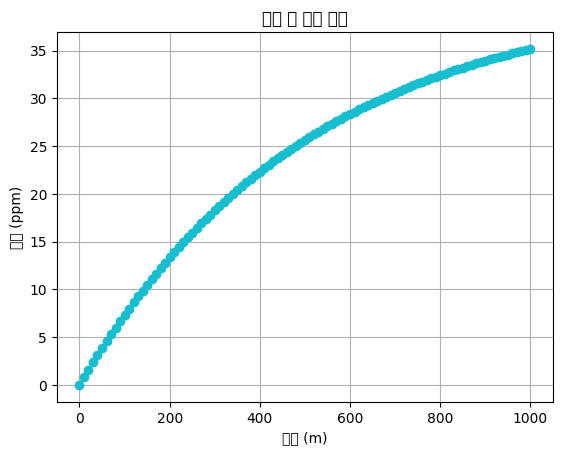

In [1]:
# [예제 6.3.4] [Python 코드작성(예)]

import numpy as np
import matplotlib.pyplot as plt
# 파라미터 설정
L = 1000  # 터널 길이 (m)
N = 101   # 격자점 수
Delta_x = L / (N - 1)  # 격자 간격 (m)
A = 50.0       # 단면적 (m^2)
V = 5
Q0 = A*V      # 초기 주류 유량 (m^3/s)
q_in = 250/L     # 단위 길이당 유입 유량 (m^3/(s*m))
q_out = 250/L    # 단위 길이당 유출 유량 (m^3/(s*m))
C_in_duct = 0.0  # 유입 덕트 농도 (ppm)
C0 =0.0        # 터널 입구부 유입농도 (ppm)
S_mass = 0.025 / (A*L)     # 단위 체적당 소스항 (kg/(m^3*s))
rho = 1.225       # CO 밀도 (kg/m^3)

# 소스항을 체적 농도로 변환 (ppm/s)
S = (S_mass / rho) * 1e6  # ppm/s
print(f"S_mass: {S_mass:.10f} kg/m3.s")
print(f"S_mass_rho: {S:.10f} ppm/s")

# 배열 초기화
Q = np.zeros(N)  # 주류 유량 배열
C = np.zeros(N)  # 농도 배열

# 경계조건
C[0] = C0  # 입구 농도 (ppm)
Q[0] = Q0

# 주류 유량 계산
for i in range(1, N):
    Q[i] = Q[i-1] + (q_in - q_out) * Delta_x

# 농도 계산 (후향차분식 적용)
for i in range(1, N):
    numerator = Q[i-1] * C[i-1] + q_in * Delta_x * C_in_duct + S * A * Delta_x
    denominator = Q[i-1] + q_in * Delta_x + q_out * Delta_x
    C[i] = numerator / denominator

# 결과 출력
for i in range(0, N, 10):
    print(f"위치 {i*Delta_x:.1f} m: 풍량={Q[i]:.2f} m^3/s, 농도={C[i]:.2f} ppm")

# 농도 분포 시각화
plt.plot(np.linspace(0, L, N), C, marker='o', color='#17becf')
plt.title('터널 내 농도 분포')
plt.xlabel('위치 (m)')
plt.ylabel('농도 (ppm)')
plt.grid(True)
plt.show()